# 03 — Modeling
**Credit Risk Scoring Pipeline | Project 1**

Steps in this notebook:
1. Load engineered features from Day 4
2. Feature selection (selector.py)
3. Stratified train/test split
4. ColumnTransformer pipeline
5. Logistic Regression baseline
6. XGBoost + LightGBM (Day 6)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys, os
warnings.filterwarnings("ignore")

sys.path.insert(0, os.path.abspath('..'))

from src.credit_risk.features.selector import CreditRiskFeatureSelector

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix, roc_curve, precision_recall_curve
)

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 1 - Load Engineered Features

In [2]:
# Load the feature we saved in 02_feature_engineering.py
df = pd.read_csv('../data/processed/features_engineered.csv')

print(f'Shape: {df.shape}')
print(f'Target distribution:')
print(df['TARGET'].value_counts(normalize=True).round(4))

# Separate features and target
X = df.drop(columns=['TARGET'])
y = df['TARGET']

print(f'\nFeature count: {X.shape[1]}')
print(f'Default rate: {y.mean()*100:.1f}%')


Shape: (307511, 93)
Target distribution:
TARGET
0    0.9193
1    0.0807
Name: proportion, dtype: float64

Feature count: 92
Default rate: 8.1%


## Step 2 - Feature Selection

In [4]:
# IMPORTANT: We fit the selector on ALL data here to get the feature list,
# but in the actual pipeline we will refit on X_train only.
# This cell is just for exploration — the real fit happens after the split.

selector = CreditRiskFeatureSelector(
    variance_threshold=0.01,
    corr_threshold=0.9,
    mi_top_k=50
)


X_sample = X.sample(n=50000, random_state=42)
y_sample = y.loc[X_sample.index]

selector.fit(X_sample, y_sample)
# selector.fit(X, y)  # ← bu satırı ekle

print('=== Feature Selection Report ===')
print(f'Original features: {X.shape[1]}')
print(f'Removed (low variance): {len(selector.low_var_cols_)}')
print(f'Removed (high correlation): {len(selector.high_corr_cols_)}')
print(f'Selected features: {len(selector.selected_cols_)}')

print('\nTop 20 features by Mutual Information:')
print(selector.mi_scores_.head(20).round(4))


=== Feature Selection Report ===
Original features: 92
Removed (low variance): 32
Removed (high correlation): 12
Selected features: 52

Top 20 features by Mutual Information:
EXT_SOURCE_2                   0.0151
EXT_SOURCE_3                   0.0120
AMT_ANNUITY_LOG                0.0117
FLAG_EMP_PHONE                 0.0096
FLAG_DOCUMENT_3                0.0084
CREDIT_GOODS_RATIO             0.0083
AMT_CREDIT                     0.0081
NAME_INCOME_TYPE_WOE           0.0061
CODE_GENDER_WOE                0.0052
EMPLOYMENT_YEARS               0.0047
REGION_RATING_CLIENT_W_CITY    0.0046
FLOORSMAX_MODE                 0.0043
OCCUPATION_TYPE_WOE            0.0043
NAME_EDUCATION_TYPE_WOE        0.0042
CREDIT_INCOME_RATIO            0.0040
DAYS_LAST_PHONE_CHANGE         0.0036
ORGANIZATION_TYPE_WOE          0.0035
NAME_HOUSING_TYPE_WOE          0.0030
AMT_REQ_CREDIT_BUREAU_YEAR     0.0029
HOUR_APPR_PROCESS_START        0.0025
dtype: float64


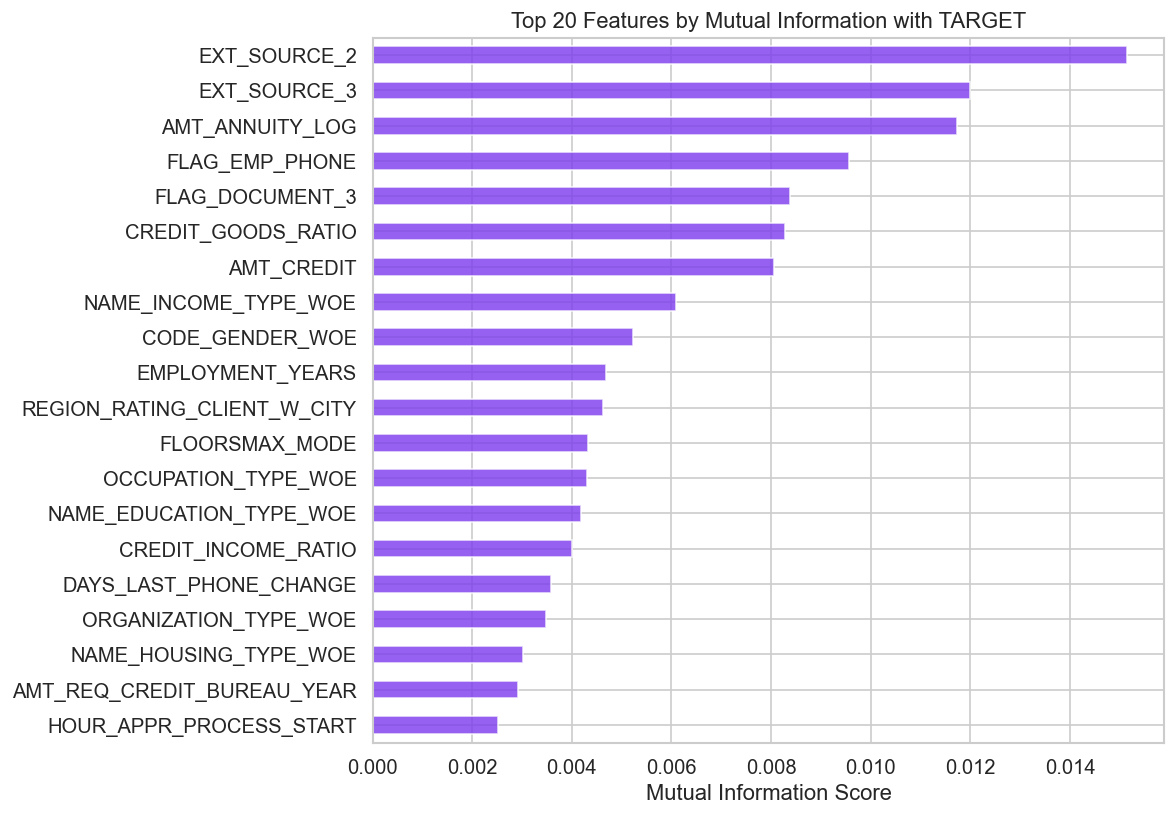

In [5]:
# Visualize the mutual information scores
top20 = selector.mi_scores_.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top20.sort_values().plot(kind='barh', ax=ax, color='#7c3aed', alpha=0.8)
ax.set_xlabel('Mutual Information Score')
ax.set_title('Top 20 Features by Mutual Information with TARGET')
plt.tight_layout()
plt.savefig('../outputs/figures/feature_mi_scores.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 3 - Stratified Train/Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'Train : {X_train.shape[0]:,} rows  |  default rate: {y_train.mean()*100:.2f}%')
print(f'Test  : {X_test.shape[0]:,} rows   |  default rate: {y_test.mean()*100:.2f}%')
print('Both rates should be ~8.1%')

Train : 246,008 rows  |  default rate: 8.07%
Test  : 61,503 rows   |  default rate: 8.07%
Both rates should be ~8.1%


## Step 4 — Selector on Train + ColumnTransformer

In [7]:
# Refit selector on train only (data leakage prevention)
X_tr_sample = X_train.sample(n=50000, random_state=RANDOM_STATE)
y_tr_sample = y_train.loc[X_tr_sample.index]

sel = CreditRiskFeatureSelector(variance_threshold=0.01, corr_threshold=0.90, mi_top_k=50)
sel.fit(X_tr_sample, y_tr_sample)

X_train_sel = sel.transform(X_train)
X_test_sel  = sel.transform(X_test)
print(f'Features after selection: {X_train_sel.shape[1]}')

num_cols = X_train_sel.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train_sel.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'Numeric: {len(num_cols)}  |  Categorical: {len(cat_cols)}')

ct = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ],
    remainder='drop'
)

X_train_proc = ct.fit_transform(X_train_sel)
X_test_proc  = ct.transform(X_test_sel)

print(f'Final train shape: {X_train_proc.shape}')
print(f'Final test  shape: {X_test_proc.shape}')

Features after selection: 52
Numeric: 52  |  Categorical: 0
Final train shape: (246008, 52)
Final test  shape: (61503, 52)


## Step 5 — Logistic Regression Baseline

In [8]:
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE,
    solver='lbfgs'
)
lr.fit(X_train_proc, y_train)

y_proba_lr = lr.predict_proba(X_test_proc)[:, 1]
y_pred_lr  = lr.predict(X_test_proc)

auc_lr   = roc_auc_score(y_test, y_proba_lr)
prauc_lr = average_precision_score(y_test, y_proba_lr)

print('=== Logistic Regression Baseline ===')
print(f'ROC-AUC : {auc_lr:.4f}')
print(f'PR-AUC  : {prauc_lr:.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=['No Default', 'Default']))

=== Logistic Regression Baseline ===
ROC-AUC : 0.7458
PR-AUC  : 0.2278

              precision    recall  f1-score   support

  No Default       0.96      0.69      0.80     56538
     Default       0.16      0.67      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503



In [11]:
from sklearn.model_selection import cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(lr, X_train_proc, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f'CV scores : {cv_scores.round(4)}')
print(f'Mean      : {cv_scores.mean():.4f}')
print(f'Std       : {cv_scores.std():.4f}  (low = stable model)')

CV scores : [0.7436 0.7415 0.7482 0.7429 0.7428]
Mean      : 0.7438
Std       : 0.0023  (low = stable model)


## Step 6 — ROC & PR Curves

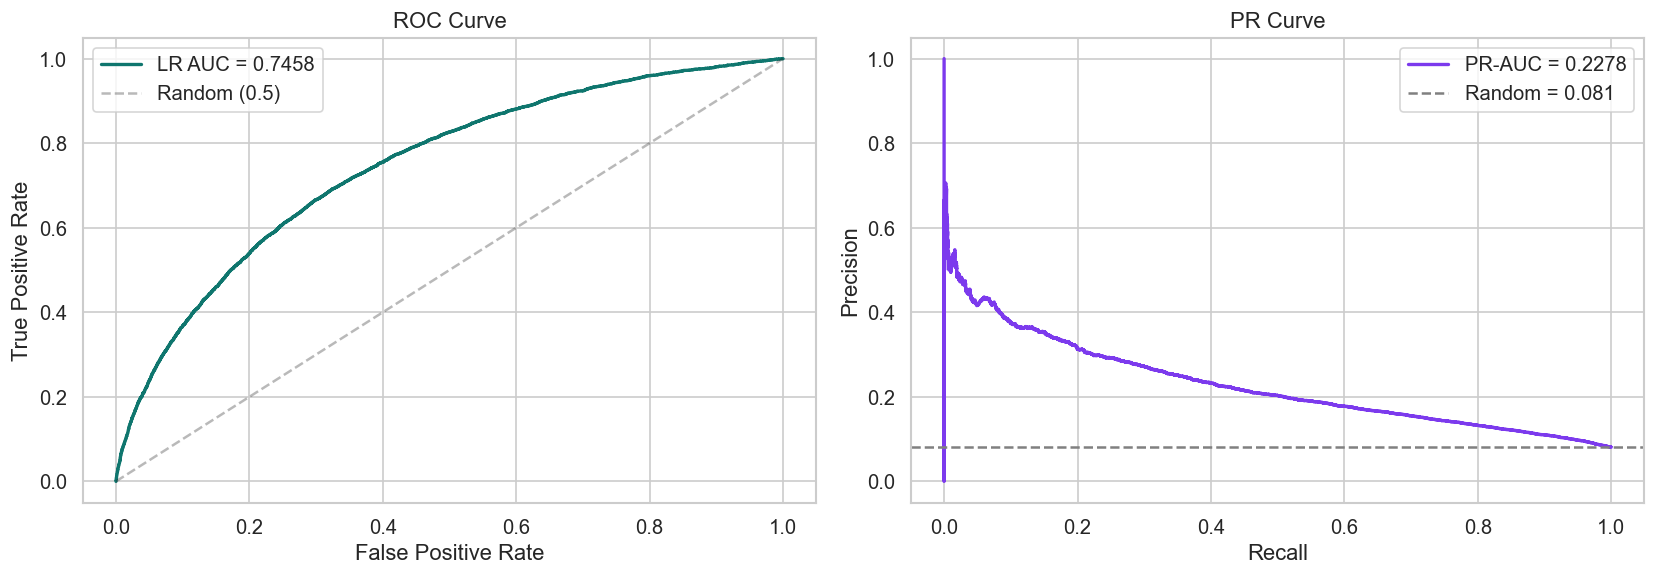

Saved: outputs/figures/lr_baseline_curves.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_test, y_proba_lr)
axes[0].plot(fpr, tpr, color='#0f766e', lw=2, label=f'LR AUC = {auc_lr:.4f}')
axes[0].plot([0,1],[0,1],'k--',alpha=0.3,label='Random (0.5)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_test, y_proba_lr)
axes[1].plot(rec, prec, color='#7c3aed', lw=2, label=f'PR-AUC = {prauc_lr:.4f}')
axes[1].axhline(y=y_test.mean(), color='gray', ls='--', label=f'Random = {y_test.mean():.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('PR Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/figures/lr_baseline_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/lr_baseline_curves.png')

## Step 7 — Save Results

In [12]:
os.makedirs('../outputs/reports', exist_ok=True)

results = pd.DataFrame([{
    'Model'       : 'Logistic Regression (baseline)',
    'ROC-AUC'     : round(auc_lr, 4),
    'PR-AUC'      : round(prauc_lr, 4),
    'CV-AUC Mean' : round(cv_scores.mean(), 4),
    'CV-AUC Std'  : round(cv_scores.std(), 4)
}])

results.to_csv('../outputs/reports/model_results.csv', index=False)
print(results.to_string(index=False))
print('\nSaved: outputs/reports/model_results.csv')
print('Ready for Day 6: XGBoost + LightGBM + Optuna')

                         Model  ROC-AUC  PR-AUC  CV-AUC Mean  CV-AUC Std
Logistic Regression (baseline)   0.7458  0.2278       0.7438      0.0023

Saved: outputs/reports/model_results.csv
Ready for Day 6: XGBoost + LightGBM + Optuna
